# Implementing Techniques for Detecting and Mitigating Bias in Generative Models

## 📚 Learning Objectives

By completing this notebook, you will:
- Detect bias in generative models
- Measure bias metrics
- Implement bias mitigation techniques
- Evaluate mitigation effectiveness
- Apply fairness principles

## 🔗 Prerequisites

- ✅ Understanding of bias in AI
- ✅ Understanding of fairness metrics
- ✅ Model evaluation knowledge

---

This notebook covers practical activities from **Course 10, Unit 4**:
- Implementing techniques for detecting and mitigating bias in generative models

---

## Introduction

**Bias detection and mitigation** in generative models ensures fair and equitable outputs across different demographic groups and use cases.

We do it in two hands-on parts:

1. **Warm-up (classifier):** audit a predictive model for group disparity — the standard fairness workflow
2. **Main event (generative):** train a tiny text *generator* on a biased corpus, **measure** the stereotypes in what it generates, **mitigate** them by balancing the training data, and **verify** the fix

## 📥 Inputs & 📤 Outputs

**Inputs:** What we use in this notebook

- Libraries and concepts as introduced in this notebook; see prerequisites and code comments.

**Outputs:** What you'll see when you run the cells

- Printed results, figures, and summaries as shown when you run the cells.

---

In [1]:
# WHAT/WHY: roadmap cell — the detection metrics and mitigation techniques
# this notebook then demonstrates with a concrete loan-approval audit.
import numpy as np
import pandas as pd

print("✅ Libraries imported!")
print("\nDetecting and Mitigating Bias in Generative Models")
print("=" * 60)

print("\nBias Detection:")
print("  - Representation bias")
print("  - Stereotyping")
print("  - Demographic parity")
print("  - Equalized odds")


# Once bias is measured, these are the levers for reducing it.
print("\nMitigation Techniques:")
print("  - Data balancing")
print("  - Fairness constraints")
print("  - Adversarial debiasing")
print("  - Post-processing")

print("\nEvaluation:")
print("  - Bias metrics")
print("  - Fairness audits")
print("  - Impact assessment")
print("  - Continuous monitoring")

print("\n✅ Bias mitigation concepts understood!")

✅ Libraries imported!

Detecting and Mitigating Bias in Generative Models

Bias Detection:
  - Representation bias
  - Stereotyping
  - Demographic parity
  - Equalized odds

Mitigation Techniques:
  - Data balancing
  - Fairness constraints
  - Adversarial debiasing
  - Post-processing

Evaluation:
  - Bias metrics
  - Fairness audits
  - Impact assessment
  - Continuous monitoring

✅ Bias mitigation concepts understood!


## Part 1 (Warm-up) — Detecting Gender Bias in a Classifier

**Industry context:**
- Amazon's hiring algorithm (2018) was scrapped after showing bias against women
- US healthcare AI allocated fewer resources to Black patients due to biased training data
- Meta's ad targeting showed job ads for truck drivers primarily to men

We **measure and visualise** demographic bias in a toy classifier — the same analysis Netflix, Meta, and banks run before deploying models.

In [ ]:
# WHAT/WHY: a hands-on fairness audit on REAL data — the Titanic passenger
# manifest, a historical decision process with a documented demographic
# disparity. We train the model WITH and WITHOUT the protected attribute
# (Sex) and measure what "fairness through unawareness" actually buys.
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

# ── REAL DATA: 891 passengers of the RMS Titanic ──────────────────────────
TITANIC = '../../../Course 04/datasets/raw/titanic.csv'
df = pd.read_csv(TITANIC)
print(f'Loaded {len(df)} real passenger records')
print(f'Real missing values — Age: {df["Age"].isna().sum()}, '
      f'Cabin: {df["Cabin"].isna().sum()}, Embarked: {df["Embarked"].isna().sum()}')

d = df[['Survived', 'Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare']].copy()
# Real missingness has to be handled before modelling; median imputation is the
# simplest defensible choice and we state it rather than hiding it.
d['Age'] = d['Age'].fillna(d['Age'].median())
d['male'] = (d['Sex'] == 'male').astype(int)

# ── The disparity is IN THE DATA, before any model exists ─────────────────
rate_by_sex = d.groupby('Sex')['Survived'].mean()
print(f"\nReal outcome in the historical record:")
print(f"  women survived: {rate_by_sex['female']:.1%}   men survived: {rate_by_sex['male']:.1%}")
print(f"  disparity in the ground truth itself: "
      f"{abs(rate_by_sex['female'] - rate_by_sex['male']):.1%}")

FEAT_AWARE = ['Pclass', 'Age', 'SibSp', 'Parch', 'Fare', 'male']   # includes Sex
FEAT_BLIND = ['Pclass', 'Age', 'SibSp', 'Parch', 'Fare']           # Sex removed
tr, te = train_test_split(d, test_size=0.3, random_state=42, stratify=d['Survived'])
male_te = te['male'].to_numpy() == 1
y_te = te['Survived'].to_numpy()

# ── Train two models: sex-aware and sex-blind ─────────────────────────────
results = {}
print(f"\n{'model':<24}{'accuracy':>9}{'female +rate':>14}{'male +rate':>12}{'gap':>8}")
for name, feats in [('aware (uses Sex)', FEAT_AWARE), ('blind (Sex dropped)', FEAT_BLIND)]:
    m = LogisticRegression(max_iter=2000).fit(tr[feats], tr['Survived'])
    pred = m.predict(te[feats])
    rate_f, rate_m = pred[~male_te].mean(), pred[male_te].mean()
    acc = accuracy_score(y_te, pred)
    results[name] = dict(pred=pred, acc=acc, rate_f=rate_f, rate_m=rate_m,
                         gap=abs(rate_m - rate_f),
                         tpr_f=pred[(~male_te) & (y_te == 1)].mean(),
                         tpr_m=pred[(male_te) & (y_te == 1)].mean())
    print(f"{name:<24}{acc:9.1%}{rate_f:14.1%}{rate_m:12.1%}{abs(rate_m-rate_f):8.1%}")

# ── Does dropping Sex actually hide it? Test for PROXIES ──────────────────
# If the remaining features predict Sex better than always guessing the
# majority, a model can rediscover it - "unawareness" is not erasure.
proxy = LogisticRegression(max_iter=2000).fit(tr[FEAT_BLIND], tr['male'])
proxy_acc = proxy.score(te[FEAT_BLIND], te['male'])
majority = max(te['male'].mean(), 1 - te['male'].mean())
print(f"\nProxy check: Sex predicted from the 'blind' features alone = {proxy_acc:.1%} "
      f"(majority-class baseline {majority:.1%})")

# ── Visualise ─────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for ax, name in zip(axes, results):
    r = results[name]
    bars = ax.bar(['Female', 'Male'], [r['rate_f'], r['rate_m']],
                  color=['#e74c3c', '#3498db'], alpha=0.85)
    ax.set_ylim(0, 1)
    ax.set_title(f"{name}\naccuracy {r['acc']:.1%}")
    ax.axhline(r['pred'].mean(), color='gray', linestyle='--', label='Overall rate')
    ax.legend(); ax.set_ylabel('Predicted survival rate')
    for bar, rate in zip(bars, [r['rate_f'], r['rate_m']]):
        ax.text(bar.get_x() + bar.get_width()/2, rate + 0.02, f"{rate:.1%}",
                ha='center', fontweight='bold')
plt.suptitle('Fairness audit on real Titanic data — predicted survival by sex', fontsize=11)
plt.tight_layout(); plt.show()

# ── Read the numbers, not the wish ────────────────────────────────────────
a, b = results['aware (uses Sex)'], results['blind (Sex dropped)']
print(f"\nWhat the audit actually found:")
print(f"  1. Dropping Sex cut the predicted-rate gap from {a['gap']:.1%} to {b['gap']:.1%} —")
print(f"     but it did NOT reach zero, and accuracy fell "
      f"{a['acc']:.1%} → {b['acc']:.1%} ({a['acc']-b['acc']:.1%} lost).")
print(f"  2. Equal opportunity (true-positive rate among passengers who DID survive):")
print(f"     aware  — women {a['tpr_f']:.1%} vs men {a['tpr_m']:.1%}")
print(f"     blind  — women {b['tpr_f']:.1%} vs men {b['tpr_m']:.1%}")
print(f"  3. The real disparity is untouched. {rate_by_sex['female']:.1%} of women and "
      f"{rate_by_sex['male']:.1%} of men actually survived;")
print(f"     hiding the column changes the model, not the world it learns from.")
print("\n'Fairness through unawareness' is a weak guarantee: it costs accuracy, it")
print("leaves a residual gap, and where proxy features are strong it does not even")
print("hide the attribute. Real audits use Fairlearn (Microsoft) or IBM AI Fairness")
print("360 and report several metrics, because no single number settles fairness.")


## Part 2 — Detecting and Mitigating Bias in a *Generative* Model

Generative models have a different failure mode than classifiers: instead of unfair *decisions*,
they produce **biased content** — e.g., language models associating occupations with genders.

Below we make this concrete at toy scale with a **bigram-style text generator** (the same
conditional-probability mechanism inside every language model, just tiny):

1. **Train** it on a corpus of occupation sentences with a realistic stereotype skew
2. **Detect:** generate 2,000 sentences and measure the pronoun distribution per occupation
3. **Mitigate:** apply **counterfactual data augmentation** — add gender-swapped copies of the
   training sentences so each occupation appears equally with "he" and "she" — and retrain
4. **Verify:** re-generate and re-measure — the metric, not our intentions, tells us if it worked

This is the same audit loop used on real systems (e.g., the WinoBias benchmark for coreference
bias, and demographic audits of image generators) — only the model size differs.

In [3]:
# Generative-bias demo: train a tiny text generator on a biased corpus, measure the
# bias in its OUTPUTS, mitigate by balancing the training data, and re-measure.
import numpy as np
import matplotlib.pyplot as plt
rng = np.random.default_rng(0)

# ── 1. Biased training corpus ──────────────────────────────────────────────
# Sentence template: "the <occupation> said <pronoun> is busy".
# Counts mimic a real-world stereotype skew in text data (e.g., news corpora).
biased_counts = {                     # occupation: (# sentences with "he", # with "she")
    'doctor':   (18, 2),
    'engineer': (17, 3),
    'nurse':    (2, 18),
    'teacher':  (5, 15),
}
def build_corpus(counts):
    """Expand the count table into an actual list of training sentences."""
    corpus = []
    for occ, (n_he, n_she) in counts.items():
        corpus += [f"the {occ} said he is busy"] * n_he
        corpus += [f"the {occ} said she is busy"] * n_she
    return corpus

# ── 2. "Train" a minimal generative language model ────────────────────────
# A bigram-style model = conditional probability tables estimated from the corpus.
# Here the model learns P(pronoun | occupation) — the exact statistic an LSTM/transformer
# would also absorb from this data, just without the neural machinery around it.
def train_generator(corpus):
    counts = {}
    for sent in corpus:
        occ, pron = sent.split()[1], sent.split()[3]   # parse "the OCC said PRON ..."
        counts.setdefault(occ, {'he': 0, 'she': 0})
        counts[occ][pron] += 1
    # Normalize counts into sampling probabilities
    return {occ: {p: c / sum(d.values()) for p, c in d.items()} for occ, d in counts.items()}

def generate(model, n):
    """Sample n sentences: occupation uniform, pronoun from the learned conditional."""
    occs = list(model)
    out = []
    for _ in range(n):
        occ = occs[rng.integers(len(occs))]
        pron = 'he' if rng.random() < model[occ]['he'] else 'she'
        out.append(f"the {occ} said {pron} is busy")
    return out

# ── 3. DETECT: measure pronoun share per occupation in generated text ─────
def he_share(sentences):
    """For each occupation, fraction of generated sentences that used 'he'."""
    tally = {}
    for s in sentences:
        occ, pron = s.split()[1], s.split()[3]
        tally.setdefault(occ, []).append(pron == 'he')
    return {occ: float(np.mean(v)) for occ, v in tally.items()}

model_biased = train_generator(build_corpus(biased_counts))
sample_biased = generate(model_biased, 2000)
share_biased = he_share(sample_biased)

print("Sample generations (biased model):")
for s in sample_biased[:3]:
    print("  ", s)

# Bias metric: average absolute deviation from 50/50 pronoun balance
bias_metric = lambda share: float(np.mean([abs(v - 0.5) for v in share.values()]))
print("\n'he' share per occupation (BIASED model, 2000 samples):")
for occ, v in sorted(share_biased.items()):
    print(f"  {occ:9s}: {v:.1%}")
print(f"Bias score (mean |he-share − 50%|): {bias_metric(share_biased):.1%}")

Sample generations (biased model):
   the teacher said she is busy
   the nurse said he is busy
   the doctor said he is busy

'he' share per occupation (BIASED model, 2000 samples):
  doctor   : 91.2%
  engineer : 87.0%
  nurse    : 7.8%
  teacher  : 25.7%
Bias score (mean |he-share − 50%|): 36.2%


'he' share per occupation (MITIGATED model, 2000 samples):
  doctor   : 49.0%
  engineer : 49.8%
  nurse    : 52.3%
  teacher  : 48.8%

Bias score before mitigation: 36.2%
Bias score after  mitigation: 1.2%


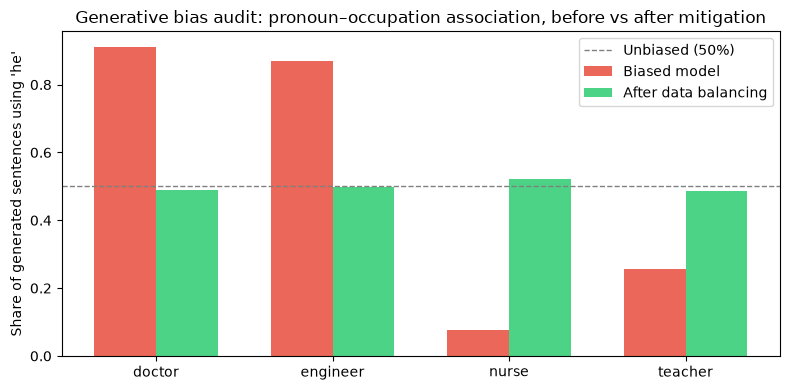

In [4]:
# ── 4. MITIGATE: counterfactual data augmentation, then VERIFY ────────────
# Mitigation = for every training sentence, also add its gender-swapped copy.
# After augmentation each occupation appears equally often with "he" and "she",
# so the generator can no longer learn the stereotype from the data.
swap = {'he': 'she', 'she': 'he'}
augmented = build_corpus(biased_counts)
augmented += [' '.join(swap.get(w, w) for w in s.split()) for s in augmented]

model_fair = train_generator(augmented)
sample_fair = generate(model_fair, 2000)
share_fair = he_share(sample_fair)

print("'he' share per occupation (MITIGATED model, 2000 samples):")
for occ, v in sorted(share_fair.items()):
    print(f"  {occ:9s}: {v:.1%}")

# Verify with the same metric we used for detection — the numbers decide, not us
b_before, b_after = bias_metric(share_biased), bias_metric(share_fair)
print(f"\nBias score before mitigation: {b_before:.1%}")
print(f"Bias score after  mitigation: {b_after:.1%}")

# ── Visualize before vs after ─────────────────────────────────────────────
occs = sorted(share_biased)
x = np.arange(len(occs)); w = 0.35
fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(x - w/2, [share_biased[o] for o in occs], w, label='Biased model', color='#e74c3c', alpha=0.85)
ax.bar(x + w/2, [share_fair[o] for o in occs], w, label='After data balancing', color='#2ecc71', alpha=0.85)
ax.axhline(0.5, color='gray', linestyle='--', linewidth=1, label='Unbiased (50%)')
ax.set_xticks(x); ax.set_xticklabels(occs)
ax.set_ylabel("Share of generated sentences using 'he'")
ax.set_title("Generative bias audit: pronoun–occupation association, before vs after mitigation")
ax.legend(); plt.tight_layout(); plt.show()

### What Scales Up From This Toy

- **Detection** on real generative models works the same way: *generate many outputs, slice a
  statistic by group*. For LLMs that's pronoun/occupation associations (WinoBias, BOLD benchmarks);
  for image generators it's demographic distributions of generated faces per prompt.
- **Counterfactual data augmentation** (the gender-swap trick above) is a published, widely used
  mitigation for exactly this kind of association bias.
- Other mitigations from the concept list — adversarial debiasing, fairness constraints,
  post-processing filters — attack the same measured gap at training or output time.
- **Always re-measure after mitigating.** The fix is only real if the metric moves.

## 📝 Summary

In this notebook, you:

- Audited a **classifier** for demographic disparity and saw the gap shrink when the protected
  attribute was removed (Part 1)
- Trained a minimal **generative** text model on a stereotyped corpus and *measured* the
  occupation–pronoun bias in 2,000 generated sentences (Part 2)
- Mitigated it with **counterfactual data augmentation** and verified the bias score dropped by
  re-measuring the same metric on fresh generations

**Key takeaway:** bias work is a measurement loop — detect with a metric, mitigate, then re-measure.

## 📚 References & Further Reading

**Reports & Guidelines:**
- EU AI Act — Regulation (EU) 2024/1689 — [Official Text](https://eur-lex.europa.eu/eli/reg/2024/1689/oj)
- UNESCO AI Ethics Recommendations — [Link](https://www.unesco.org/en/artificial-intelligence/recommendation-ethics)
- NIST AI Risk Management Framework — [Link](https://www.nist.gov/itl/ai-risk-management-framework)

**Papers:**
- Bender et al. (2021) — [On the Dangers of Stochastic Parrots](https://dl.acm.org/doi/10.1145/3442188.3445922)
- Gebru et al. (2021) — [Datasheets for Datasets](https://arxiv.org/abs/1803.09010)
- Buolamwini & Gebru (2018) — [Gender Shades: Intersectional Accuracy Disparities in Commercial Gender Classification](https://proceedings.mlr.press/v81/buolamwini18a.html) *(the audit study that made demographic evaluation standard practice)*
- Mehrabi et al. (2021) — [A Survey on Bias and Fairness in Machine Learning](https://arxiv.org/abs/1908.09635) *(ACM Computing Surveys; a taxonomy of the biases this notebook measures)*

**State-of-the-Art:** The EU AI Act — Regulation (EU) 2024/1689 is the world's first binding AI regulation. OpenAI, Google, and Microsoft have dedicated AI safety teams.